# Why XGBoost often performs well

**XGBoost** is an implementation of gradient boosting, where trees are built sequentially. Each new tree focuses on correcting the errors made by the previous trees. Compared with a single decision tree or even a random forest, XGBoost typically provides:

Higher predictive accuracy
Built-in regularization to reduce overfitting
Handling of missing values
Parallelized tree construction for speed
Feature importance scores
Early stopping to avoid unnecessary training

For many structured/tabular datasets (such as fraud detection, recommendation features, customer churn, and credit scoring), XGBoost is one of the strongest baseline models to try.

In [1]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier


In [2]:
data = load_breast_cancer()

X= data.data
y= data.target


In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

In [7]:
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
y_preds = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test,y_preds)
print("Accuracy:",accuracy)
print(classification_report(y_test,y_preds))

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



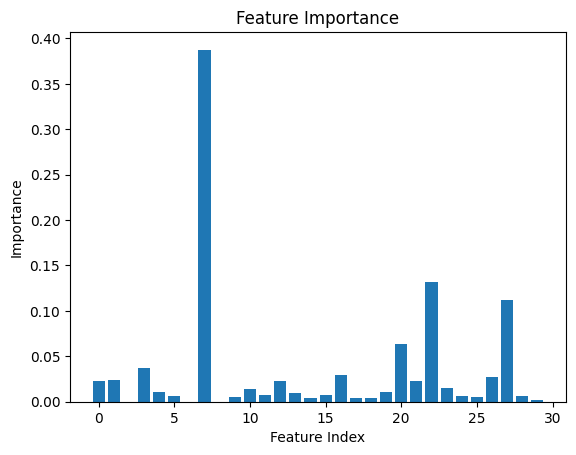

In [10]:
import matplotlib.pyplot as plt
import numpy as np

importance = model.feature_importances_
plt.bar(range(len(importance)),importance)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [11]:
probabilities = model.predict_proba(X_test)


In [12]:
print(probabilities[:5])

[[1.0517180e-02 9.8948282e-01]
 [9.9828911e-01 1.7108959e-03]
 [9.9770051e-01 2.2994615e-03]
 [1.4207363e-03 9.9857926e-01]
 [7.2187185e-04 9.9927813e-01]]


# Regression Example

In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

MSE: 0.23878951548874885
